<a href="https://colab.research.google.com/github/Kdshah1512/Academics-projects/blob/main/gemstone_price_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Gemstone Price Prediction**

**Problem Statement**

The developing a machine learning model that predicts the price of the gemstones based on attributes such as carat, cut, color, clarity, depth, and dimensions. This problem addresses a regression-type prediction of the price of gemstones based on its given attributes. The dataset contains various characteristics related to gemstones, and it is one of the major objectives of this work to make a determination on how these features affect the price and model them properly for precise predictions.


Loading required libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn import tree
from sklearn.preprocessing import OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression,Lasso,Ridge,ElasticNet
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeRegressor

Reading the dataset

In [ ]:
df = pd.read_csv('/content/gemstone.csv')
df.head()

,id,carat,cut,color,clarity,depth,table,x,y,z,price
0,0,1.52,Premium,F,VS2,62.2,58.0,7.27,7.33,4.55,13619
1,1,2.03,Very Good,J,SI2,62.0,58.0,8.06,8.12,5.05,13387
2,2,0.70,Ideal,G,VS1,61.2,57.0,5.69,5.73,3.50,2772
3,3,0.32,Ideal,G,VS1,61.6,56.0,4.38,4.41,2.71,666
4,4,1.70,Premium,G,VS2,62.6,59.0,7.65,7.61,4.77,14453


In [ ]:
df.dtypes

,0
id,int64
carat,float64
cut,object
color,object
clarity,object
depth,float64
table,float64
x,float64
y,float64
z,float64


Independent and dependent features

In [ ]:

X = df.drop(labels=['price'],axis=1)
Y = df[['price']]

In [ ]:
df.shape

(193573, 11)

cleaning dataset

In [ ]:
df.isnull().sum()

,0
id,0
carat,0
cut,0
color,0
clarity,0
depth,0
table,0
x,0
y,0
z,0


In [ ]:
df.info

<bound method DataFrame.info of             id  carat        cut color clarity  depth  table     x     y  \
0            0   1.52    Premium     F     VS2   62.2   58.0  7.27  7.33   
1            1   2.03  Very Good     J     SI2   62.0   58.0  8.06  8.12   
2            2   0.70      Ideal     G     VS1   61.2   57.0  5.69  5.73   
3            3   0.32      Ideal     G     VS1   61.6   56.0  4.38  4.41   
4            4   1.70    Premium     G     VS2   62.6   59.0  7.65  7.61   
...        ...    ...        ...   ...     ...    ...    ...   ...   ...   
193568  193568   0.31      Ideal     D    VVS2   61.1   56.0  4.35  4.39   
193569  193569   0.70    Premium     G    VVS2   60.3   58.0  5.75  5.77   
193570  193570   0.73  Very Good     F     SI1   63.1   57.0  5.72  5.75   
193571  193571   0.34  Very Good     D     SI1   62.9   55.0  4.45  4.49   
193572  193572   0.71       Good     E     SI2   60.8   64.0  5.73  5.71   

           z  price  
0       4.55  13619  
1       5.05  13387  
2       3.50   2772  
3       2.71    666  
4       4.77  14453  
...      ...    ...  
193568  2.67   1130  
193569  3.47   2874  
193570  3.62   3036  
193571  2.81    681  
193572  3.48   2258  

[193573 rows x 11 columns]>

In [ ]:
df.value_counts()

,,,,,,,,,,,count
id,carat,cut,color,clarity,depth,table,x,y,z,price,
0,1.52,Premium,F,VS2,62.2,58.0,7.27,7.33,4.55,13619,1
129053,1.50,Very Good,G,VS2,63.2,59.0,7.20,7.27,4.57,12787,1
129044,0.71,Ideal,E,SI1,61.3,57.0,5.74,5.77,3.52,2329,1
129045,0.40,Ideal,E,VS1,62.1,55.0,4.73,4.75,2.95,947,1
129046,0.70,Very Good,H,SI1,61.8,55.0,5.69,5.66,3.50,2060,1
...,...,...,...,...,...,...,...,...,...,...,...
64526,1.51,Very Good,E,SI1,59.7,58.0,7.42,7.49,4.44,12539,1
64527,0.71,Premium,E,SI1,62.7,60.0,5.65,5.62,3.54,2631,1
64528,0.52,Ideal,I,VS1,61.6,56.0,5.16,5.18,3.19,1401,1


In [ ]:
Y

,price
0,13619
1,13387
2,2772
3,666
4,14453
...,...
193568,1130
193569,2874
193570,3036
193571,681


numerical and categorical pipeline






In [ ]:
cut_categories = ['Fair', 'Good', 'Very Good', 'Premium', 'Ideal']
color_categories = ['D', 'E', 'F', 'G', 'H', 'I', 'J']
clarity_categories = ['I1', 'SI2', 'SI1', 'VS2', 'VS1', 'VVS2', 'VVS1', 'IF']

In [ ]:

num_pipeline=Pipeline(
    steps=[
    ('imputer',SimpleImputer(strategy='median')),
    ('scaler',StandardScaler())

    ]

)


cat_pipeline=Pipeline(
    steps=[
    ('imputer',SimpleImputer(strategy='most_frequent')),
    ('ordinalencoder',OrdinalEncoder(categories=[cut_categories,color_categories,clarity_categories])),
    ('scaler',StandardScaler())
    ]

)
numerical_cols = ['carat', 'depth', 'table', 'x', 'y', 'z']
categorical_cols = ['cut', 'color', 'clarity']
preprocessor=ColumnTransformer([
('num_pipeline',num_pipeline,numerical_cols),
('cat_pipeline',cat_pipeline,categorical_cols)
])
print(num_pipeline)



Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler())])


Data visulisation

In [ ]:
df[['carat', 'depth', 'table']].corr()

,carat,depth,table
carat,1.000000,0.027852,0.225737
depth,0.027852,1.000000,-0.230631
table,0.225737,-0.230631,1.000000


Heatmap

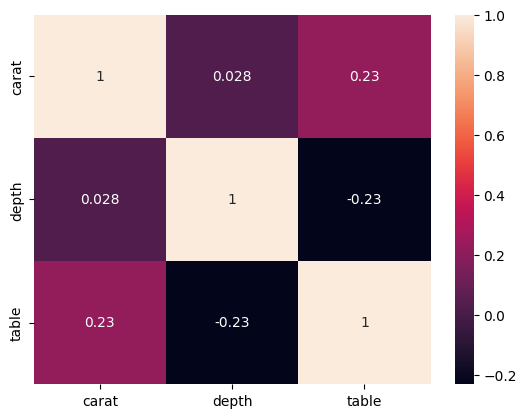

In [ ]:
sns.heatmap(df[['carat', 'depth', 'table']].corr(), annot=True)
plt.show()

correlation of carat vs price

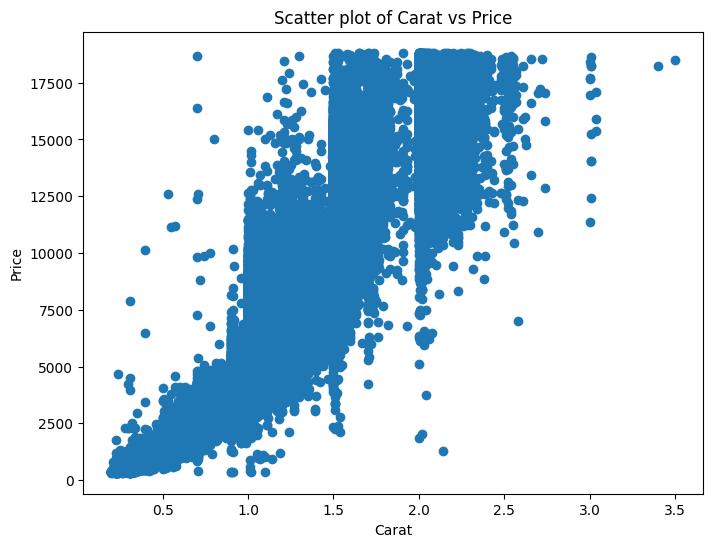

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(df['carat'], df['price'])
plt.xlabel("Carat")
plt.ylabel("Price")
plt.title("Scatter plot of Carat vs Price")
plt.show()

Train test split

In [ ]:
X_train,X_test,y_train,y_test=train_test_split(X,Y,test_size=0.30,random_state=30)
X_train=pd.DataFrame(preprocessor.fit_transform(X_train),columns=preprocessor.get_feature_names_out())
X_test=pd.DataFrame(preprocessor.transform(X_test),columns=preprocessor.get_feature_names_out())

In [ ]:
X_train.head()



,num_pipeline__carat,num_pipeline__depth,num_pipeline__table,num_pipeline__x,num_pipeline__y,num_pipeline__z,cat_pipeline__cut,cat_pipeline__color,cat_pipeline__clarity
0,-0.975439,-0.849607,-0.121531,-1.042757,-1.080970,-1.123150,0.874076,1.528722,1.352731
1,0.235195,1.833637,-0.121531,0.318447,0.279859,0.485354,-2.144558,-0.935071,-0.646786
2,0.494617,0.815855,0.399800,0.570855,0.606458,0.673737,-0.132136,0.296826,0.686225
3,-1.018676,0.260701,0.921131,-1.214034,-1.244270,-1.195605,-0.132136,0.296826,0.019720
4,-0.953821,-0.664555,-0.642862,-1.069801,-1.044681,-1.094168,0.874076,2.144670,1.352731


In [ ]:
X_train.shape

(135501, 9)

**Test ML Methods**

In [ ]:
len(X_train)

135501

In [ ]:
len(X_test)

58072

In [ ]:
len(y_train)

135501

In [ ]:
len(y_test)

58072

 LinearRegression

In [ ]:
regression=LinearRegression()
regression.fit(X_train,y_train)

LinearRegression()

In [ ]:
regression.coef_

array([[ 6433.66003594,  -132.75843566,   -70.42922179, -1720.30971463,
         -499.29302619,   -63.39317848,    72.44537247,  -460.41604642,
          650.76431652]])

In [ ]:
regression.intercept_

array([3970.76628955])

Train multiple models and
evaluate model

In [ ]:

def evaluate_model(true, predicted):
    mae = mean_absolute_error(true, predicted)
    mse = mean_squared_error(true, predicted)
    rmse = np.sqrt(mean_squared_error(true, predicted))
    r2_square = r2_score(true, predicted)
    return mae, rmse, r2_square

In [ ]:

models={
    'DecisionTreeRegressor':DecisionTreeRegressor(),

    'LinearRegression':LinearRegression(),
    'Lasso':Lasso(),
    'Ridge':Ridge(),
    'Elasticnet':ElasticNet(),
}
trained_model_list=[]
model_list=[]
r2_list=[]

for i in range(len(list(models))):
    model=list(models.values())[i]
    model.fit(X_train,y_train)


    y_pred=model.predict(X_test)

    mae, rmse, r2_square=evaluate_model(y_test,y_pred)

    print(list(models.keys())[i])
    model_list.append(list(models.keys())[i])

    print('Model Training Performance')
    print("RMSE:",rmse)
    print("MAE:",mae)
    print("accuracy",r2_square*100)

    r2_list.append(r2_square)

    print('='*35)
    print('\n')




DecisionTreeRegressor
Model Training Performance
RMSE: 838.6425404387396
MAE: 423.1093355374937
accuracy 95.68230460949204


LinearRegression
Model Training Performance
RMSE: 1013.9047094344002
MAE: 674.025511579685
accuracy 93.68908248567512


Lasso
Model Training Performance
RMSE: 1013.8784226767013
MAE: 675.0716923362156
accuracy 93.68940971841704


Ridge
Model Training Performance
RMSE: 1013.9059272771406
MAE: 674.0555800798531
accuracy 93.68906732505968


Elasticnet
Model Training Performance
RMSE: 1533.4162456064046
MAE: 1060.7368759154729
accuracy 85.56494831165182




**check model with highest accuracy score**

In [ ]:
model_list
r2_list

best_model_index = r2_list.index(max(r2_list))
best_model = model_list[best_model_index]

print(f"\nThe model with the highest accuracy score is: {best_model}")


The model with the highest accuracy score is: DecisionTreeRegressor


**Conclusion**

The job is to design a regression model for predicting gemstone prices, given the features like carat, cut, color, clarity, and dimensions. Categorical features like cut, color, and clarity encoders might also have been implemented, with numerical feature scaling just before regression model development. The models can be used for checking, such as Random Forest, Linear Regression, ElasticNet,DecisionTreeRegressor,Lasso.